<a href="https://colab.research.google.com/github/ViniciusMontanaro/ViniciusMontanaro/blob/main/rerruptura.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

# Modelos
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB


In [14]:
from google.colab import files
uploaded = files.upload()

df = pd.read_excel("final.xlsx")  # substitua pelo nome do arquivo
df.head()


Saving final.xlsx to final (2).xlsx


,Lado,Sexo,Nascimento,Idade na cirurgia,Data da cirurgia,Goutalier Supra,% infiltração supra,Goutalier Infra,% infiltração infra,Goutalier Sub,...,Classificação Cofield,Cofield AP (cm).1,Cofield LM (cm).1,Cuff,Deltoid,C/D,Stump,Reparo parcial,Tecnica,rerruptura
0,Direito,F,1971-03-31,53.004791,2024-04-01,1,0.0937,1,0.0641,0,...,Grande,4.0,3.3,70.4,101.00,0.697,1,0.0,speedfix,0
1,Direito,M,1972-04-11,51.972621,2024-04-01,1,0.1320,1,0.1030,1,...,Média,1.3,1.5,52.0,128.00,0.406,1,0.0,F. simples,0
2,Direito,F,1966-07-29,57.686516,2024-04-05,1,0.0554,1,0.0556,0,...,Média,2.0,1,117.0,84.75,1.381,3,0.0,speedfix,1
3,Esquerdo,F,1959-06-25,64.780287,2024-04-05,0,0.0746,0,0.0820,0,...,Pequena,0.5,0.5,79.0,83.00,0.952,2,0.0,Speedfix,1
4,Direito,M,1980-06-22,43.800137,2024-04-10,1,0.0975,1,0.0771,1,...,Média,1.0,1.5,66.0,101.00,0.653,1,0.0,speedfix,1


In [27]:
# Padronizar nomes das colunas para evitar erros
df.columns = df.columns.str.strip()      # remove espaços extras
df.columns = df.columns.str.lower()      # coloca tudo em minúsculo

print(df.columns.tolist())  # conferir os nomes padronizados

# Remover colunas de datas (ajuste para os nomes padronizados)
df = df.drop(['nascimento','data da cirurgia'], axis=1, errors='ignore')

# Limpar a coluna 'rerruptura' antes de definir y
df['rerruptura'] = pd.to_numeric(df['rerruptura'], errors='coerce')
df.dropna(subset=['rerruptura'], inplace=True)
df['rerruptura'] = df['rerruptura'].astype(int)

# Variável dependente (ajuste para o nome padronizado do desfecho)
y = df['rerruptura']   # substitua pelo nome exato após padronizar

# Variáveis independentes (convertendo categóricas em numéricas)
X = pd.get_dummies(df.drop('rerruptura', axis=1), drop_first=True)

# Garantir que todas as colunas em X sejam numéricas e com NaNs explícitos antes da imputação
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Imputar valores ausentes em X antes da divisão treino/teste
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean') # ou 'median', 'most_frequent'
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Normalização
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

['lado', 'sexo', 'idade na cirurgia', 'goutalier supra', '% infiltração supra', 'goutalier infra', '% infiltração infra', 'goutalier sub', '% subesc,', 'gfdi %', 'gfdi', 'ruptura', 'cofield ap (cm)', 'cofield lm (cm)', 'colesterol', 'diabetes', 'obesidadde', 'collins classification', 'constant', 'ucla', 'ucla em %', 'força elevação', 'força re', 'força ri', 'ct', 'warner', 'tangente', 'ucla pós', 'ucla em % pós', 'constant pós', 'força elevação pós', 'força re pós', 'força ri pós', 'ct pós', 'cl biceps', 'classif, geométrica', '% supra(axial)', 'classificação cofield', 'cofield ap (cm).1', 'cofield lm (cm).1', 'cuff', 'deltoid', 'c/d', 'stump', 'reparo parcial', 'tecnica', 'rerruptura']


In [18]:
from sklearn.neural_network import MLPClassifier

parametros = {
    "Logistic Regression": (LogisticRegression(max_iter=1000),
                            {"C":[0.01,0.1,1,10], "solver":["lbfgs","liblinear"]}),

    "SVM": (SVC(probability=True),
            {"C":[0.1,1,10], "kernel":["linear","rbf"], "gamma":["scale","auto"]}),

    "Random Forest": (RandomForestClassifier(),
                      {"n_estimators":[100,200], "max_depth":[None,10,20]}),

    "Naive Bayes": (GaussianNB(),
                    {}),  # sem hiperparâmetros relevantes

    "Gradient Boosting": (GradientBoostingClassifier(),
                          {"n_estimators":[100,200], "learning_rate":[0.01,0.1,0.2]}),

    "MLPClassifier": (MLPClassifier(max_iter=1000),
                      {"hidden_layer_sizes":[(50,),(100,)], "activation":["relu","tanh"], "solver":["adam","sgd"]})
}

In [28]:
from sklearn.model_selection import GridSearchCV

resultados = {}
y_pred_proba_dict = {}

for nome, (modelo, params) in parametros.items():
    if params:  # se houver hiperparâmetros
        grid = GridSearchCV(modelo, params, cv=5, scoring='roc_auc', n_jobs=-1)
        grid.fit(X_train, y_train)
        melhor_modelo = grid.best_estimator_
    else:  # Naive Bayes
        melhor_modelo = modelo
        melhor_modelo.fit(X_train, y_train)

    y_pred = melhor_modelo.predict(X_test)
    y_pred_proba = melhor_modelo.predict_proba(X_test)[:,1] if hasattr(melhor_modelo,"predict_proba") else None

    resultados[nome] = {
        "Melhor Modelo": melhor_modelo,
        "Acurácia": accuracy_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else "N/A",
        "Matriz Confusão": confusion_matrix(y_test, y_pred),
        "Relatório": classification_report(y_test, y_pred)
    }
    if y_pred_proba is not None:
        y_pred_proba_dict[nome] = y_pred_proba

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [29]:
for nome, res in resultados.items():
    print(f"\nModelo: {nome}")
    print("Melhor Modelo:", res["Melhor Modelo"])
    print("Acurácia:", res["Acurácia"])
    print("ROC AUC:", res["ROC AUC"])
    print("Matriz de Confusão:\n", res["Matriz Confusão"])
    print("Relatório de Classificação:\n", res["Relatório"])




Modelo: Logistic Regression
Melhor Modelo: LogisticRegression(C=0.01, max_iter=1000)
Acurácia: 0.6551724137931034
ROC AUC: 0.8
Matriz de Confusão:
 [[12  2]
 [ 8  7]]
Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.60      0.86      0.71        14
           1       0.78      0.47      0.58        15

    accuracy                           0.66        29
   macro avg       0.69      0.66      0.64        29
weighted avg       0.69      0.66      0.64        29


Modelo: SVM
Melhor Modelo: SVC(C=0.1, gamma='auto', probability=True)
Acurácia: 0.4827586206896552
ROC AUC: 0.780952380952381
Matriz de Confusão:
 [[14  0]
 [15  0]]
Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.48      1.00      0.65        14
           1       0.00      0.00      0.00        15

    accuracy                           0.48        29
   macro avg       0.24      0.50      0.33        29
weighted

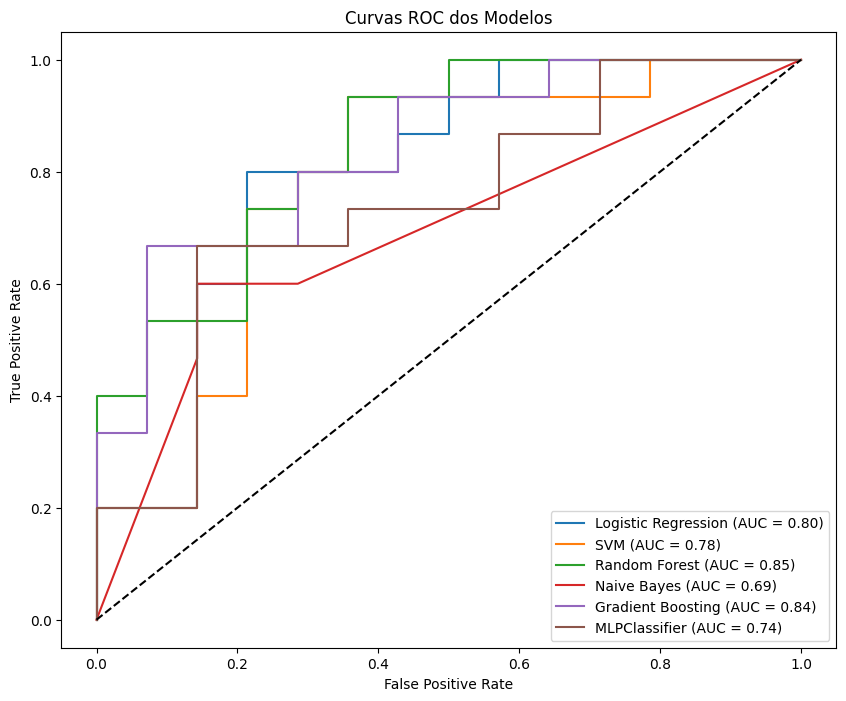

In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10,8))

for nome, y_pred_proba in y_pred_proba_dict.items():
    # Certifique-se de que y_pred_proba não é 'N/A' e é um array ou Series
    if isinstance(y_pred_proba, np.ndarray):
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{nome} (AUC = {roc_auc:.2f})')
    else:
        print(f"Não foi possível plotar ROC para {nome} devido a valores inválidos em y_pred_proba.")

plt.plot([0,1],[0,1],'k--')  # linha diagonal
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curvas ROC dos Modelos')
plt.legend(loc='lower right')
plt.show()